# Notebook 2: Spectral Action — Deriving alpha_G from Riemann Zeros

The gravitational coupling is determined by the spectral action:
$S_{\rm grav} = \sum_{n=1}^{N_*} \ln(t_n / t_1)$

where $t_n$ are the imaginary parts of the Riemann zeta zeros.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'font.family': 'serif'})

# First 30 Riemann zeros
zeros = np.array([
    14.134725, 21.022040, 25.010858, 30.424876, 32.935062,
    37.586178, 40.918719, 43.327073, 48.005151, 49.773832,
    52.970321, 56.446248, 59.347044, 60.831779, 65.112544,
    67.079811, 69.546402, 72.067158, 75.704691, 77.144840,
    79.337375, 82.910381, 84.735493, 87.425275, 88.809111,
    92.491899, 94.651344, 95.870634, 98.831194, 101.317851,
])

alpha_em = 1/137.036
alpha_G_obs = 5.9061e-39

# Target spectral action
S_target = -np.pi/2 * np.log(alpha_G_obs)
print(f"Target S_grav = (pi/2) * ln(1/alpha_G) = {S_target:.2f}")
print(f"Compare: 1/alpha_em = {1/alpha_em:.3f}")
print(f"Difference: {S_target - 1/alpha_em:.2f} ({(S_target - 1/alpha_em)/(1/alpha_em)*100:.1f}%)")

Target S_grav = (pi/2) * ln(1/alpha_G) = 138.27
Compare: 1/alpha_em = 137.036
Difference: 1.23 (0.9%)


In [2]:
# Cumulative spectral action
S_cumulative = np.cumsum(np.log(zeros / zeros[0]))
n_arr = np.arange(1, len(zeros) + 1)

print(f"{'N zeros':>8} {'S_grav':>10} {'alpha_G (pred)':>15} {'Ratio to obs':>12}")
print("-" * 50)
for i in [4, 9, 14, 19, 24, 29]:
    aG = np.exp(-2 * S_cumulative[i] / np.pi)
    print(f"{i+1:8d} {S_cumulative[i]:10.2f} {aG:15.4e} {aG/alpha_G_obs:12.2e}")

# Extrapolate: how many zeros needed?
def S_asymptotic(N):
    return N * np.log(2*np.pi*N/zeros[0]) - N - S_target

N_needed = brentq(S_asymptotic, 10, 1000)
print(f"\nZeros needed for exact alpha_G: N* ~ {N_needed:.0f}")

 N zeros     S_grav  alpha_G (pred) Ratio to obs
--------------------------------------------------
       5       2.58      1.9348e-01     3.28e+37
      10       8.22      5.3280e-03     9.02e+35
      15      15.35      5.7011e-05     9.65e+33
      20      23.51      3.1718e-07     5.37e+31
      25      32.45      1.0670e-09     1.81e+29
      30      42.06      2.3524e-12     3.98e+26

Zeros needed for exact alpha_G: N* ~ 60


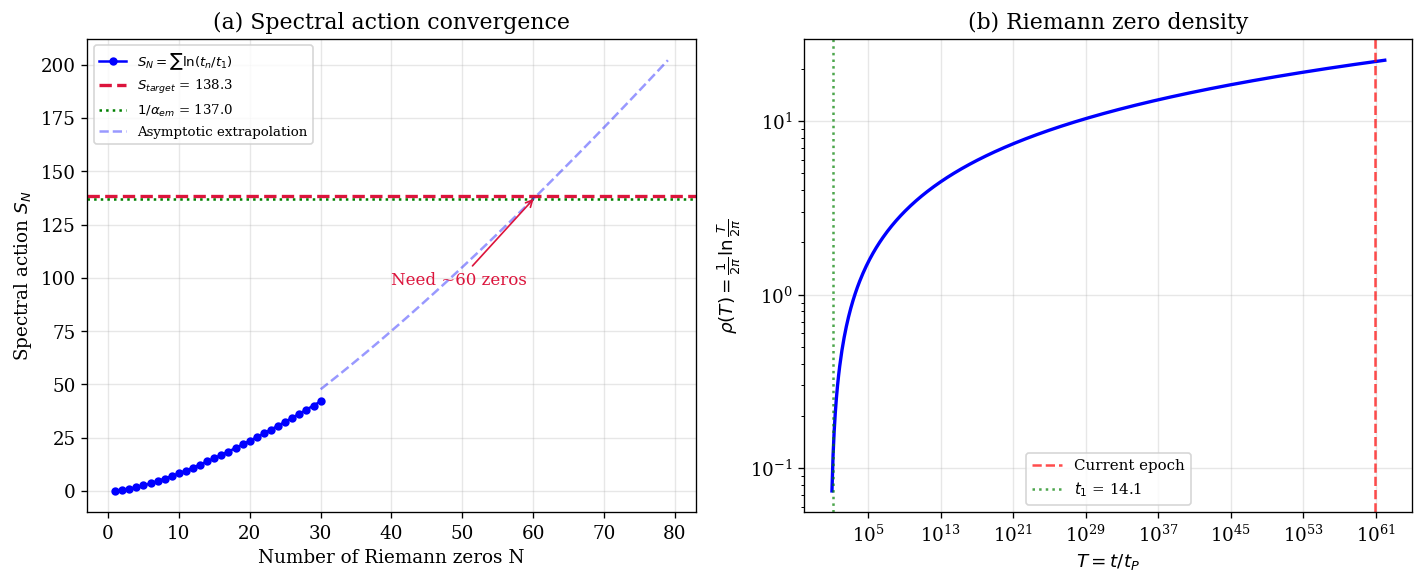

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# (a) Spectral action convergence
ax1.plot(n_arr, S_cumulative, 'bo-', markersize=4, lw=1.5, label='$S_N = \\sum \\ln(t_n/t_1)$')
ax1.axhline(S_target, color='crimson', ls='--', lw=2, label=f'$S_{{target}}$ = {S_target:.1f}')
ax1.axhline(1/alpha_em, color='green', ls=':', lw=1.5, label=f'$1/\\alpha_{{em}}$ = {1/alpha_em:.1f}')

# Extrapolate
N_ext = np.arange(1, 80)
S_ext = N_ext * np.log(2*np.pi*N_ext/zeros[0]) - N_ext
ax1.plot(N_ext[29:], S_ext[29:], 'b--', alpha=0.4, label='Asymptotic extrapolation')

ax1.set_xlabel('Number of Riemann zeros N')
ax1.set_ylabel('Spectral action $S_N$')
ax1.set_title('(a) Spectral action convergence')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.annotate(f'Need ~{N_needed:.0f} zeros', xy=(N_needed, S_target),
             xytext=(40, S_target*0.7), fontsize=10, color='crimson',
             arrowprops=dict(arrowstyle='->', color='crimson'))

# (b) Riemann zero density
def rho(T):
    return np.log(np.maximum(T, 2.1) / (2*np.pi)) / (2*np.pi)

T_arr = np.logspace(1, 62, 500)
ax2.loglog(T_arr, rho(T_arr), 'b-', lw=2)
t_P = 5.39e-44
t_0 = 4.35e17
T_now = t_0 / t_P
ax2.axvline(T_now, color='red', ls='--', alpha=0.7, label=f'Current epoch')
ax2.axvline(zeros[0], color='green', ls=':', alpha=0.7, label=f'$t_1$ = {zeros[0]:.1f}')
ax2.set_xlabel('$T = t/t_P$')
ax2.set_ylabel(r'$\rho(T) = \frac{1}{2\pi}\ln\frac{T}{2\pi}$')
ax2.set_title('(b) Riemann zero density')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_spectral_action.png', dpi=150, bbox_inches='tight')
plt.show()